Importar librerías
- `Numpy`: cálculos vectoriales
- `Matplotlib.pyplot`: Ver los resultados
- `copy`: Para duplicar hábitats

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random
import copy

Definir las funciones de prueba $\mathcal{T}_1$ - $\mathcal{T}_6$ *(Zitzler et al.)*

In [12]:
# T1: Frente Convexo
def test_T1(x):
    m = len(x)
    f1 = x[0]
    g = 1.0 + 9.0 * np.sum(x[1:]) / (m - 1)
    h = 1.0 - np.sqrt(f1 / g)
    f2 = g * h
    return f1, f2

# T2: Frente No Convexo
def test_T2(x):
    m = len(x)
    f1 = x[0]
    g = 1.0 + 9.0 * np.sum(x[1:]) / (m - 1)
    h = 1.0 - (f1 / g)**2
    f2 = g * h
    return f1, f2

# T3: Frente Discreto
def test_T3(x):
    m = len(x)
    f1 = x[0]
    g = 1.0 + 9.0 * np.sum(x[1:]) / (m - 1)
    h = 1.0 - np.sqrt(f1 / g) - (f1 / g) * np.sin(10 * np.pi * f1)
    f2 = g * h
    return f1, f2

# T4: Frente Multimodal
def test_T4(x):
    m = len(x)
    f1 = x[0]
    g = 1.0 + 10.0 * (m - 1) + np.sum([xi**2 - 10.0 * np.cos(4 * np.pi * xi) for xi in x[1:]])
    h = 1.0 - np.sqrt(f1 / g)
    f2 = g * h
    return f1, f2

# T5: Frente Deceptivo (Bits)
def test_T5(x_list):
    
    u_x1 = np.sum(x_list[0])
    f1 = 1.0 + u_x1
    
    g = 0
    for i in range(1, len(x_list)):
        u_xi = np.sum(x_list[i])
        if u_xi < 5:
            v_u = 2.0 + u_xi
        else: # u_xi == 5
            v_u = 1.0
        g += v_u
        
    h = 1.0 / f1
    f2 = g * h
    return f1, f2

# T6: Frente No Uniforme
def test_T6(x):
    m = len(x)
    f1 = 1.0 - np.exp(-4 * x[0]) * (np.sin(6 * np.pi * x[0])**6)
    g = 1.0 + 9.0 * (np.sum(x[1:]) / (m - 1))**0.25
    h = 1.0 - (f1 / g)**2
    f2 = g * h
    return f1, f2

### Definir el "hábitat" (solucion)
Esta clase representa una solución individual (un hábitat). Almacena sus SIVs (la solución en sí), HSI (fitness) y las tasas de migración

In [ ]:
import numpy as np
import copy

class Habitat:
    def __init__(self, problem_type, m, bounds, bit_lengths=None):
        self.problem_type = problem_type # 'float' o 'bits' necesario para T5
        self.m = m # Número de variables (SIVs)
        self.bounds = bounds # Lista de tuplas (min, max) para floats
        self.bit_lengths = bit_lengths # Lista de longitudes para test_T5() si es 'bits'
        
        self.sivs = [] # Suitability Index Variables (variables de solución)
        
        if self.problem_type == 'float':
            # Vectorizar la inicialización de SIVs
            self.low_bounds = np.array([b[0] for b in self.bounds])
            self.high_bounds = np.array([b[1] for b in self.bounds])
            self.sivs = np.random.uniform(self.low_bounds, self.high_bounds, size=self.m)
        
        elif self.problem_type == 'bits':
            # Para bits, el bucle es necesario ya que tienen longitudes diferentes
            self.sivs = [np.random.randint(0, 2, size=length) for length in self.bit_lengths]

        # HSI y Tasas
        self.hsi = float('inf') # Habitat Suitability Index (valor de la función objetivo a minimizar)
        self.lambda_ = 0.0 # Tasa de inmigración del hábitat
        self.mu = 0.0 # Tasa de emigración del hábitat

    def clone(self): # Crea una copia idéntica de este hábitat
        return copy.deepcopy(self)

    def check_bounds(self): # Asegura que los SIVs estén dentro de los límites (solo para floats)
        if self.problem_type == 'float':
            self.sivs = np.clip(self.sivs, self.low_bounds, self.high_bounds)

Implemenar el algoritmo BBO

In [ ]:
def run_bbo(test_function, problem_type, m, bounds, bit_lengths, 
            pop_size, generations, weights, 
            max_migration, elitism_param, mutation_rate):
    
    # 1. INICIALIZACIÓN
    # Crear la población inicial como un array de clase Habitat
    poblacion = [Habitat(problem_type, m, bounds, bit_lengths) for _ in range(pop_size)]
    
    # Pre-calcular una matriz de SIVs (para migración 'float')
    if problem_type == 'float':
        all_sivs = np.array([h.sivs for h in poblacion])
    
    # Bucle de Generaciones
    for gen in range(generations):
        
        # 2. CÁLCULO DE HSI (FITNESS)
        for hab in poblacion:
            f1, f2 = test_function(hab.sivs)
            hab.hsi = (weights[0] * f1) + (weights[1] * f2)
            
        poblacion.sort(key=lambda h: h.hsi)
        
        # 3. ELITISMO
        elite_set = [hab.clone() for hab in poblacion[:elitism_param]]
        
        # 4. MAPEO DE TASAS
        # Pre-calcular tasas para una asignación más rápida
        ranks = np.arange(pop_size)
        lambda_rates = max_migration * (1.0 - (ranks / pop_size))
        mu_rates = max_migration * (ranks / pop_size)
        
        for k, hab in enumerate(poblacion):
            hab.lambda_ = lambda_rates[k]
            hab.mu = mu_rates[k]
            
        # 5. MIGRACIÓN
        new_poblacion = [] + elite_set # Empezar con la élite
        
        # Pre-calcular probabilidades de donación
        suma_mu = np.sum(mu_rates)
        prob_mu = mu_rates / suma_mu if suma_mu > 0 else np.full(pop_size, 1/pop_size)
        
        if problem_type == 'float':
            all_sivs = np.array([h.sivs for h in poblacion]) # (pop_size, m)

        for i in range(elitism_param, pop_size):
            hab_modificado = poblacion[i].clone()

            if hab_modificado.problem_type == 'float':
                # Inicio vectorización
                # Decidir qué SIVs migrar (todos a la vez)
                migrate_mask = np.random.rand(m) < hab_modificado.lambda_
                
                # Si no hay nada que migrar, saltar
                if not np.any(migrate_mask):
                    new_poblacion.append(hab_modificado)
                    continue

                # Elegir m donantes (uno por cada "ranura" SIV)
                donor_indices = np.random.choice(pop_size, size=m, p=prob_mu)
                
                # Obtener el SIV 'j' del donante elegido para 'j'
                donor_sivs = all_sivs[donor_indices, np.arange(m)]
                
                # Reemplazar solo los SIVs donde migrate_mask es True
                hab_modificado.sivs = np.where(migrate_mask, donor_sivs, hab_modificado.sivs)
                # Fin vectorización
                
            elif hab_modificado.problem_type == 'bits':
                # Para bits (m=11), el bucle es pequeño y está bien
                for j in range(m):
                    if random.random() < hab_modificado.lambda_:
                        hab_donante = np.random.choice(poblacion, p=prob_mu)
                        hab_modificado.sivs[j] = copy.deepcopy(hab_donante.sivs[j])

            new_poblacion.append(hab_modificado)
        
        poblacion = new_poblacion

        # 6. MUTACIÓN
        for i in range(elitism_param, pop_size): # No mutar la élite
            hab = poblacion[i]
            
            if hab.problem_type == 'float':
                # --- INICIO VECTORIZACIÓN (MUTACIÓN) ---
                mutate_mask = np.random.rand(m) < mutation_rate
                
                # Generar un vector completo de nuevos SIVs aleatorios
                random_sivs = np.random.uniform(hab.low_bounds, hab.high_bounds, size=m)
                
                # Reemplazar solo donde mutate_mask es True
                hab.sivs = np.where(mutate_mask, random_sivs, hab.sivs)
                # --- FIN VECTORIZACIÓN ---
                
            elif hab.problem_type == 'bits':
                for j in range(m):
                    if random.random() < mutation_rate:
                        bit_idx = random.randint(0, len(hab.sivs[j]) - 1)
                        hab.sivs[j][bit_idx] = 1 - hab.sivs[j][bit_idx]

    # Fin del bucle de generaciones
    
    # 7. CÁLCULO FINAL Y RETORNO
    final_results = []
    for hab in poblacion:
        f1, f2 = test_function(hab.sivs)
        # Recalcular el HSI con los pesos actuales
        hsi_final = (weights[0] * f1) + (weights[1] * f2)
        final_results.append((f1, f2, hsi_final))
        
    # Ordenar por el HSI final
    final_results.sort(key=lambda x: x[2])
    
    # Devolver el mejor (f1, f2)
    return final_results[0][0], final_results[0][1]

# Ejecución y Gráfico

Test $\mathcal{T}_1$

Ejecutando BBO para test_T1...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0.55
  Ejecutando con pesos: w1

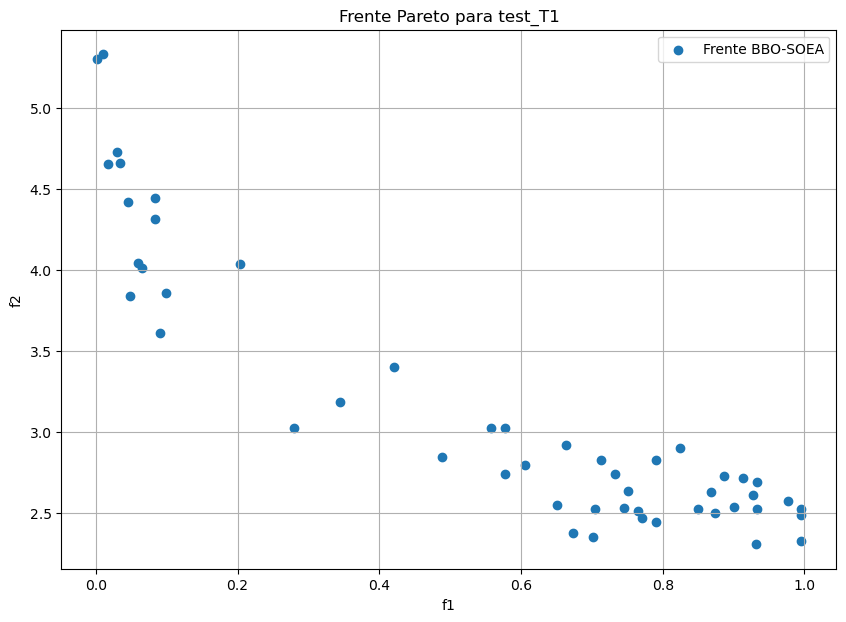

In [ ]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO ---
TARGET_FUNCTION = test_T1
PROBLEM_TYPE = 'float' # 'float' o 'bits'
M_VARS = 30 # Número de variables de decisión
BOUNDS = [(0, 1)] * M_VARS # Límites para cada variable
BIT_LENGTHS = None # Usar None si no es 'bits'

# 2. HIPERPARÁMETROS DE BBO
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2 # Cuántas mejores soluciones guardar (elitismo)
MAX_MIGRATION = 1.0 # Tasa máxima de migración (I y E)
MUTATION_RATE = 0.05

# 3. CONFIGURACIÓN DEL WRAPPER SOEA
N_PESOS = 50 # Cuántos puntos calcular para el frente
pesos_list = np.linspace(0, 1, N_PESOS)

# 4. EJECUCIÓN
print(f"Ejecutando BBO para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        mutation_rate=MUTATION_RATE
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# 5. GRÁFICA DE RESULTADOS
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Implementación Test $\mathcal{T}_2$ (No Convexa)

Ejecutando BBO para test_T2...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0.55
  Ejecutando con pesos: w1

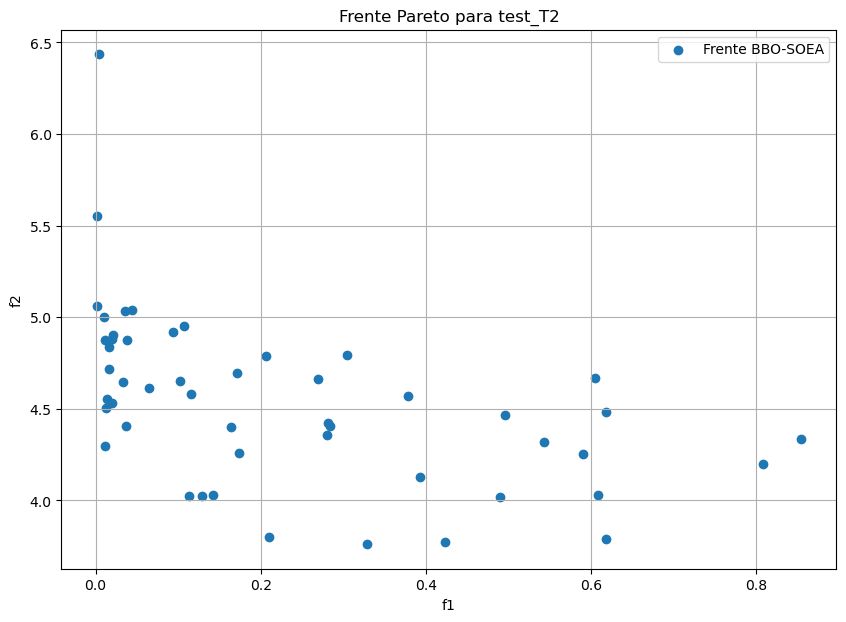

In [17]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO (T2) ---
TARGET_FUNCTION = test_T2
PROBLEM_TYPE = 'float'
M_VARS = 30
BOUNDS = [(0, 1)] * M_VARS
BIT_LENGTHS = None

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2 
MAX_MIGRATION = 1.0 
MUTATION_RATE = 0.05

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50 
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        mutation_rate=MUTATION_RATE
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Implementación Test $\mathcal{T}_3$ (Discreta)

Ejecutando BBO para test_T3...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0.55
  Ejecutando con pesos: w1

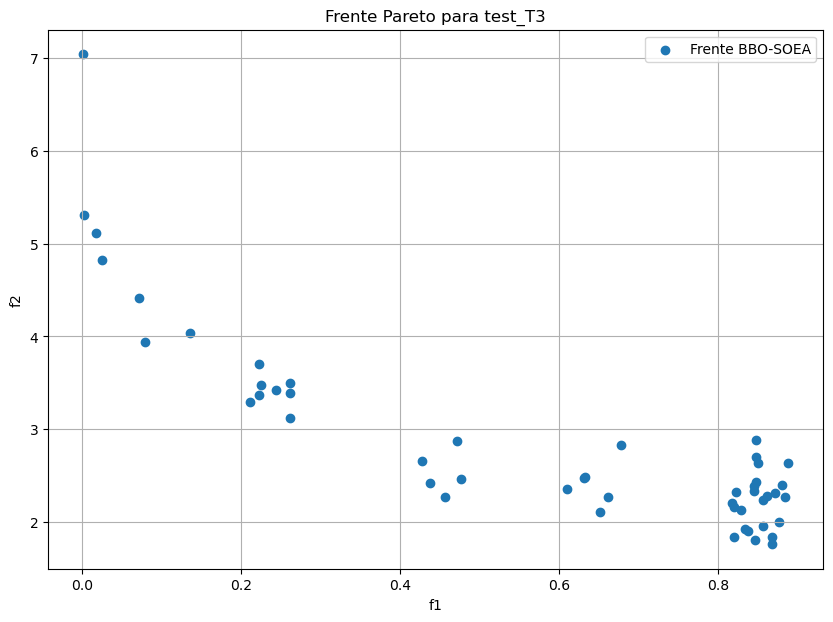

In [18]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO (T3) ---
TARGET_FUNCTION = test_T3
PROBLEM_TYPE = 'float'
M_VARS = 30
BOUNDS = [(0, 1)] * M_VARS
BIT_LENGTHS = None

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2 
MAX_MIGRATION = 1.0 
MUTATION_RATE = 0.05

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50 
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        mutation_rate=MUTATION_RATE
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Implementación Test $\mathcal{T}_4$ (Multimodal)

Ejecutando BBO para test_T4...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0.55
  Ejecutando con pesos: w1

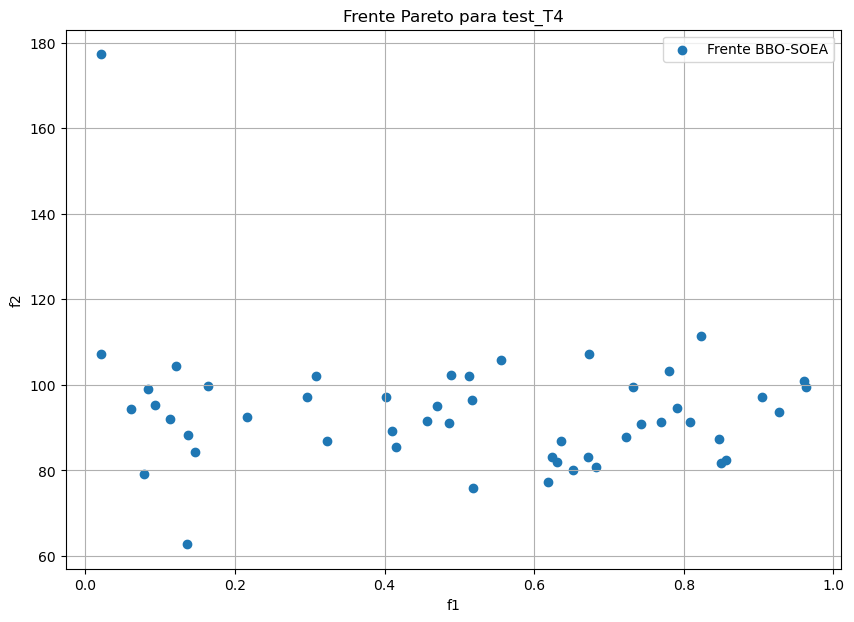

In [19]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO (T4) ---
TARGET_FUNCTION = test_T4
PROBLEM_TYPE = 'float'
M_VARS = 10
BOUNDS = [(0, 1)] + [(-5, 5)] * (M_VARS - 1)
BIT_LENGTHS = None

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2 
MAX_MIGRATION = 1.0 
MUTATION_RATE = 0.05

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50 
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        mutation_rate=MUTATION_RATE
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Implementación Test $\mathcal{T}_5$ (Deceptiva)

Ejecutando BBO para test_T5...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0.55
  Ejecutando con pesos: w1

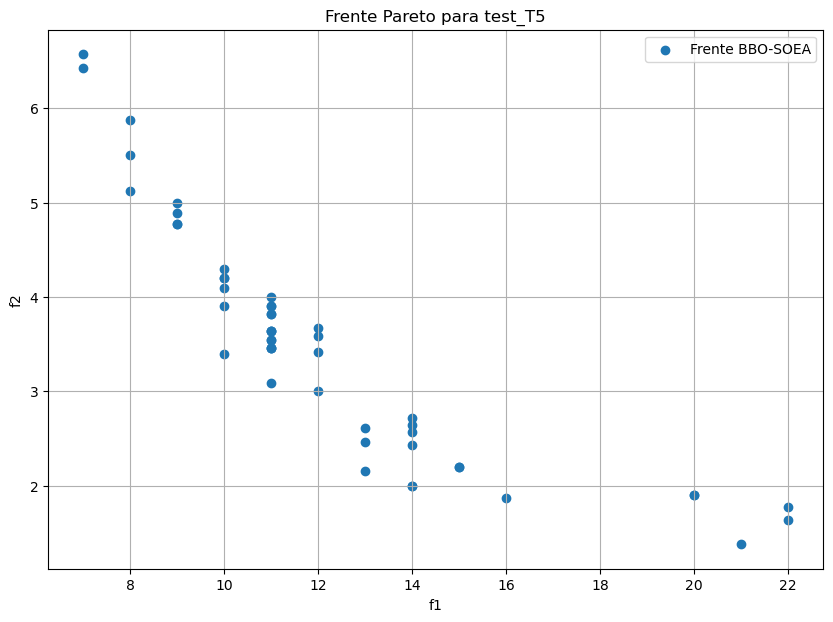

In [20]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO (T5) ---
TARGET_FUNCTION = test_T5
PROBLEM_TYPE = 'bits'
M_VARS = 11 # 1 (x1) + 10 (x2 a x11)
BOUNDS = None
# x1 tiene 30 bits, las otras 10 tienen 5 bits
BIT_LENGTHS = [30] + [5] * 10

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2 
MAX_MIGRATION = 1.0 
MUTATION_RATE = 0.05

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50 
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        mutation_rate=MUTATION_RATE
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Implementación Test $\mathcal{T}_6$ (No Uniforme)

Ejecutando BBO para test_T6...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0.55
  Ejecutando con pesos: w1

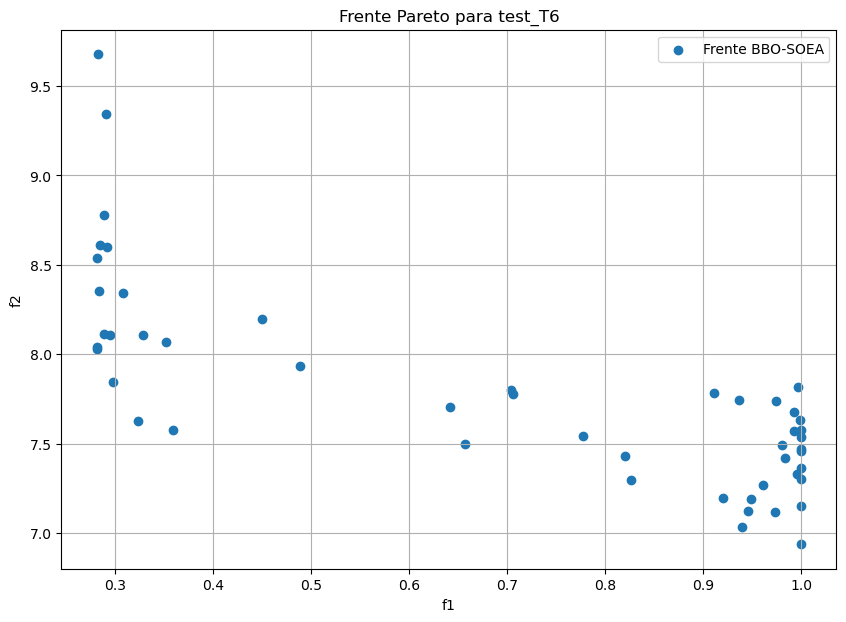

In [21]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO (T6) ---
TARGET_FUNCTION = test_T6
PROBLEM_TYPE = 'float'
M_VARS = 10 # [cite: 890]
BOUNDS = [(0, 1)] * M_VARS # [cite: 890]
BIT_LENGTHS = None

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2 
MAX_MIGRATION = 1.0 
MUTATION_RATE = 0.05

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50 
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        mutation_rate=MUTATION_RATE
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()